# Visualizacao de Token Pruning com Checkpoints

Este notebook adapta a ideia de visualizacao do DynamicViT para os modelos deste projeto. Ele pega uma imagem real do Flowers102, carrega varios checkpoints `.pth`, roda inferencia e mostra quais patches foram mantidos/removidos em cada estagio de pruning.

Modelos incluidos:

- Teacher / baseline sem pruning.
- Top-K conservador.
- Top-K agressivo.
- Trend-Adjusted Pruning.
- Class-Aware Trend Pruning.
- Trend-Adjusted Pruning com Knowledge Distillation.
- Class-Aware Trend Pruning com Knowledge Distillation.

A visualizacao usa os indices de patches mantidos por `PrunedViT.last_keep_indices`. O class token nunca aparece na imagem porque ele nao corresponde a um patch visual.


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision.datasets import Flowers102
from torchvision import transforms

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model.pruned_vit import create_pruned_vit_model
from model.vit import create_vit_model
from data.transforms import IMAGENET_MEAN, IMAGENET_STD
from utils import load_config, load_checkpoint


In [ ]:
DATA_DIR = PROJECT_ROOT / "dataset"
IMAGE_SIZE = 224
PATCH_SIZE = 16
GRID_SIZE = IMAGE_SIZE // PATCH_SIZE
SAMPLE_INDEX = 1235
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "viz_pruned_vit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_SPECS = [
    {
        "label": "teacher",
        "display_name": "Teacher / baseline",
        "model_type": "teacher",
        "config_path": PROJECT_ROOT / "configs" / "optuna_best.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\optuna_best_teacher_full\checkpoints\optuna_best_best.pth"),
    },
    {
        "label": "topk_normal",
        "display_name": "Top-K conservador",
        "model_type": "pruned",
        "config_path": PROJECT_ROOT / "configs" / "pruning" / "pruning_topk.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\pruning_topk_results\checkpoints\pruning_topk_best.pth"),
    },
    {
        "label": "topk_aggressive",
        "display_name": "Top-K agressivo",
        "model_type": "pruned",
        "config_path": PROJECT_ROOT / "configs" / "pruning" / "agressive_pruning_topk.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\agressive_pruning_topk_results\checkpoints\agressive_pruning_topk_best.pth"),
    },
    {
        "label": "trend_adjusted",
        "display_name": "Trend-Adjusted",
        "model_type": "pruned",
        "config_path": PROJECT_ROOT / "configs" / "pruning" / "trend_adjusted_pruning.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\trend_adjusted_pruning_results\checkpoints\trend_adjusted_pruning_best.pth"),
    },
    {
        "label": "class_aware_trend",
        "display_name": "Class-Aware Trend",
        "model_type": "pruned",
        "config_path": PROJECT_ROOT / "configs" / "pruning" / "class_aware_trend_pruning.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\class_aware_trend_pruning_results\checkpoints\class_aware_trend_pruning_best.pth"),
    },
    {
        "label": "trend_adjusted_kd",
        "display_name": "Trend-Adjusted + KD",
        "model_type": "pruned",
        "config_path": PROJECT_ROOT / "configs" / "pruning" / "trend_adjusted_pruning_kd.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\trend_adjusted_pruning_kd_results\checkpoints\trend_adjusted_pruning_kd_best.pth"),
    },
    {
        "label": "class_aware_trend_kd",
        "display_name": "Class-Aware Trend + KD",
        "model_type": "pruned",
        "config_path": PROJECT_ROOT / "configs" / "pruning" / "class_aware_trend_pruning_kd.yaml",
        "checkpoint_path": Path(r"C:\Users\ccost\Documents\deep-learning\class_aware_trend_pruning_kd_results\checkpoints\class_aware_trend_pruning_kd_best.pth"),
    },
]

print("Device:", device)
print("Output dir:", OUTPUT_DIR)

for spec in MODEL_SPECS:
    print("\n", spec["display_name"])
    print("  Config:", spec["config_path"], "OK" if spec["config_path"].exists() else "NAO ENCONTRADO")
    print("  Checkpoint:", spec["checkpoint_path"], "OK" if spec["checkpoint_path"].exists() else "NAO ENCONTRADO")


In [ ]:
resize_crop = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
])

to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

dataset = Flowers102(
    root=DATA_DIR,
    split="test",
    transform=None,
    download=True,
)

raw_image, label = dataset[SAMPLE_INDEX]
image = resize_crop(raw_image.convert("RGB"))
image_tensor = to_tensor(image).unsqueeze(0).to(device)

print("Label:", label)
print("Image size:", image.size)


In [ ]:
def create_model_from_spec(spec, config):
    if spec["model_type"] == "teacher":
        return create_vit_model(
            num_classes=config["dataset"]["num_classes"],
            pretrained=False,
            model_name=config["model"]["name"],
        )

    pruning_config = config["pruning"]
    return create_pruned_vit_model(
        num_classes=config["dataset"]["num_classes"],
        pretrained=False,
        model_name=config["model"]["name"],
        prune_layers=pruning_config["prune_layers"],
        keep_ratios=pruning_config["keep_ratios"],
        score_method=pruning_config.get("score_method", "token_norm"),
        pruning_method=pruning_config.get("method", "topk"),
        history_config=pruning_config.get("history"),
        preserve_order=pruning_config.get("preserve_order", True),
        track_token_indices=True,
    )


def run_inference(spec):
    config = load_config(spec["config_path"])
    model = create_model_from_spec(spec, config)
    model, checkpoint = load_checkpoint(
        model=model,
        checkpoint_path=spec["checkpoint_path"],
        device=device,
    )
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        logits = model(image_tensor)

    pred = logits.argmax(dim=1).item()
    proba = logits.softmax(dim=1)[0, pred].item()

    if spec["model_type"] == "teacher":
        token_counts = [GRID_SIZE * GRID_SIZE + 1]
        keep_indices = []
        pruning_method = "none"
        prune_layers = []
    else:
        token_counts = model.last_token_counts
        keep_indices = [indices.detach().cpu() for indices in model.last_keep_indices]
        pruning_method = config["pruning"].get("method", "topk")
        prune_layers = config["pruning"]["prune_layers"]

    return {
        "spec": spec,
        "config": config,
        "checkpoint": checkpoint,
        "pred": pred,
        "proba": proba,
        "token_counts": token_counts,
        "keep_indices": keep_indices,
        "pruning_method": pruning_method,
        "prune_layers": prune_layers,
    }


results = []

for spec in MODEL_SPECS:
    print(f"Rodando: {spec['display_name']}")
    assert spec["config_path"].exists(), f"Config nao encontrada: {spec['config_path']}"
    assert spec["checkpoint_path"].exists(), f"Checkpoint nao encontrado: {spec['checkpoint_path']}"
    result = run_inference(spec)
    results.append(result)
    print(
        f"  method={result['pruning_method']} | "
        f"epoch={result['checkpoint'].get('epoch')} | "
        f"best={result['checkpoint'].get('best_metric')} | "
        f"real={label} | pred={result['pred']} | conf={result['proba']:.4f} | "
        f"tokens={result['token_counts']}"
    )


In [ ]:
def image_to_patch_tokens(image):
    image_array = np.asarray(image.convert("RGB"))
    return image_array.reshape(
        GRID_SIZE,
        PATCH_SIZE,
        GRID_SIZE,
        PATCH_SIZE,
        3,
    ).swapaxes(1, 2).reshape(
        GRID_SIZE * GRID_SIZE,
        PATCH_SIZE,
        PATCH_SIZE,
        3,
    )


def recover_image_from_patch_tokens(tokens):
    return tokens.reshape(
        GRID_SIZE,
        GRID_SIZE,
        PATCH_SIZE,
        PATCH_SIZE,
        3,
    ).swapaxes(1, 2).reshape(IMAGE_SIZE, IMAGE_SIZE, 3)


def mask_removed_patches(image, keep_indices, alpha=0.2):
    tokens = image_to_patch_tokens(image).astype(np.float32)
    keep_indices = set(int(i) for i in keep_indices)
    removed_indices = [i for i in range(GRID_SIZE * GRID_SIZE) if i not in keep_indices]
    tokens[removed_indices] = alpha * tokens[removed_indices] + (1.0 - alpha) * 255.0
    return recover_image_from_patch_tokens(tokens).astype(np.uint8)


def get_stage_images(result):
    stage_images = []
    for keep_indices in result["keep_indices"]:
        stage_images.append(mask_removed_patches(image, keep_indices[0].numpy()))
    return stage_images


In [ ]:
original = np.asarray(image.convert("RGB"))

for result in results:
    spec = result["spec"]
    stage_images = get_stage_images(result)
    images = [original] + stage_images
    titles = ["Original"] + [
        f"Bloco {layer}: {len(result['keep_indices'][i][0])} patches"
        for i, layer in enumerate(result["prune_layers"])
    ]

    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(
        f"{spec['display_name']} | real={label} | pred={result['pred']} | "
        f"conf={result['proba']:.3f} | tokens={result['token_counts'][-1]}"
    )
    plt.tight_layout()

    output_path = OUTPUT_DIR / f"{spec['label']}_sample_{SAMPLE_INDEX}.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print("Salvo em:", output_path)
    plt.show()


In [ ]:
max_cols = 1 + max(len(result["keep_indices"]) for result in results)
fig, axes = plt.subplots(
    len(results),
    max_cols,
    figsize=(4 * max_cols, 3.6 * len(results)),
)

if len(results) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, result in enumerate(results):
    spec = result["spec"]
    stage_images = get_stage_images(result)
    images = [original] + stage_images
    titles = ["Original"] + [
        f"B{layer}: {len(result['keep_indices'][i][0])}"
        for i, layer in enumerate(result["prune_layers"])
    ]

    for col_idx in range(max_cols):
        ax = axes[row_idx, col_idx]
        ax.axis("off")

        if col_idx < len(images):
            ax.imshow(images[col_idx])
            ax.set_title(titles[col_idx])

        if col_idx == 0:
            ylabel = (
                f"{spec['display_name']}\n"
                f"pred={result['pred']} | conf={result['proba']:.2f}\n"
                f"tokens={result['token_counts'][-1]}"
            )
            ax.set_ylabel(
                ylabel,
                rotation=0,
                labelpad=80,
                va="center",
            )

fig.suptitle(f"Comparacao de Token Pruning | amostra={SAMPLE_INDEX} | rotulo real={label}")
plt.tight_layout()

combined_path = OUTPUT_DIR / f"comparison_sample_{SAMPLE_INDEX}.png"
fig.savefig(combined_path, dpi=200, bbox_inches="tight")
print("Figura comparativa salva em:", combined_path)
plt.show()


## Comparacao direta: Top-K agressivo vs Class-Aware Trend + KD

Esta figura isola o baseline Top-K agressivo e o metodo proposto com Knowledge Distillation. Ambos usam o mesmo or?amento de tokens (`197 -> 158 -> 104 -> 58`), entao a comparacao visual foca no criterio de selecao dos patches.


Figura para relatorio salva em: c:\Users\ccost\Documents\vit-token-pruning\notebooks\outputs\viz_pruned_vit\topk_vs_class_aware_kd_sample_1235.png


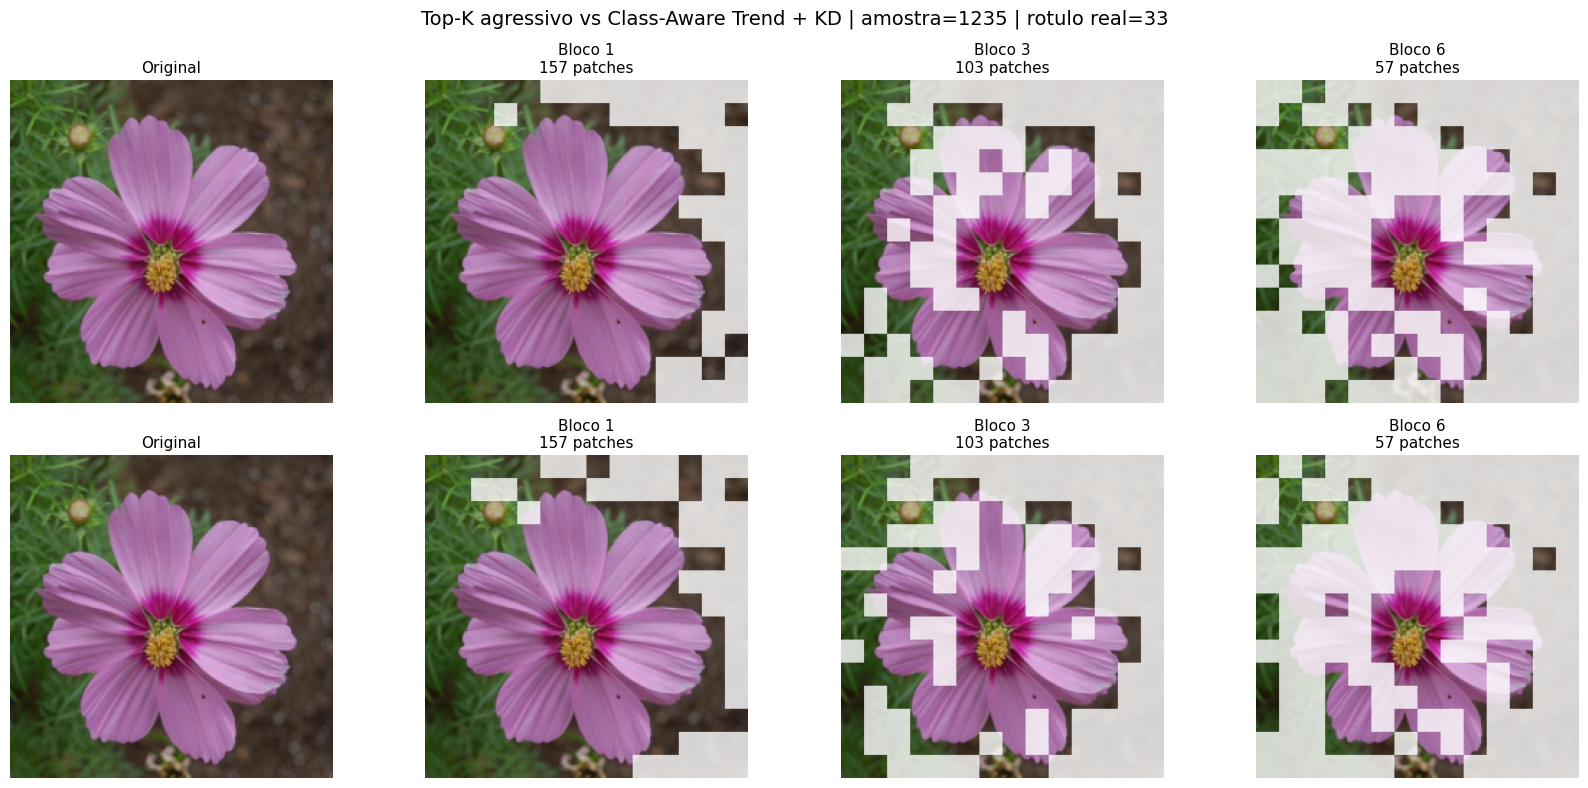

In [10]:
comparison_labels = ["topk_aggressive", "class_aware_trend_kd"]
comparison_results = [
    result for result in results
    if result["spec"]["label"] in comparison_labels
]
comparison_results = sorted(
    comparison_results,
    key=lambda result: comparison_labels.index(result["spec"]["label"]),
)

assert len(comparison_results) == len(comparison_labels), "Algum modelo da comparacao nao foi encontrado em results."

max_cols = 1 + max(len(result["keep_indices"]) for result in comparison_results)
fig, axes = plt.subplots(
    len(comparison_results),
    max_cols,
    figsize=(4.2 * max_cols, 4.0 * len(comparison_results)),
)

if len(comparison_results) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, result in enumerate(comparison_results):
    spec = result["spec"]
    stage_images = get_stage_images(result)
    images = [original] + stage_images
    titles = ["Original"] + [
        f"Bloco {layer}\n{len(result['keep_indices'][i][0])} patches"
        for i, layer in enumerate(result["prune_layers"])
    ]

    for col_idx in range(max_cols):
        ax = axes[row_idx, col_idx]
        ax.axis("off")

        if col_idx < len(images):
            ax.imshow(images[col_idx])
            ax.set_title(titles[col_idx], fontsize=11)

        if col_idx == 0:
            ylabel = (
                f"{spec['display_name']}\n"
                f"pred={result['pred']} | conf={result['proba']:.2f}\n"
                f"tokens={result['token_counts'][-1]}"
            )
            ax.set_ylabel(
                ylabel,
                rotation=0,
                labelpad=82,
                va="center",
                fontsize=11,
            )

fig.suptitle(
    f"Top-K agressivo vs Class-Aware Trend + KD | amostra={SAMPLE_INDEX} | rotulo real={label}",
    fontsize=14,
)
plt.tight_layout()

report_comparison_path = OUTPUT_DIR / f"topk_vs_class_aware_kd_sample_{SAMPLE_INDEX}.png"
fig.savefig(report_comparison_path, dpi=300, bbox_inches="tight")
print("Figura para relatorio salva em:", report_comparison_path)
plt.show()


## Observacoes

- O teacher aparece apenas com a imagem original, pois nao remove tokens.
- Os demais modelos mostram os patches sobreviventes em cada estagio de pruning.
- As figuras sao salvas em `notebooks/outputs/viz_pruned_vit/`.
- Este notebook usa `track_token_indices=True`, entao ele e adequado para explicabilidade/visualizacao, nao para benchmark de latencia.
